# Customer Churn Analysis & Retention Strategy

## 1. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand customer behavior, identify important patterns, and discover relationships between customer characteristics and churn.

The analysis will focus on:

- Overall churn distribution
- Customer tenure
- Monthly and total charges
- Contract types
- Payment methods
- Paperless billing
- Senior citizen status
- Differences between churned and retained customers

The findings from this phase will guide the advanced statistical analysis and business recommendations.

## 2. Import Required Libraries

The following libraries are used for data manipulation, statistical analysis, and visualization.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Cleaned Dataset

The validated dataset created during the data-cleaning phase will be used for exploratory analysis.

In [55]:
# Load the cleaned dataset
DATA_PATH = "../data/cleaned_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully: {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully: 500 rows and 9 columns.


## 4. Overall Customer Churn

The first analysis measures the proportion of customers who have churned compared with customers who have remained with the business.

This provides a baseline churn rate for the entire customer population.

In [56]:
# Calculate the number of churned and retained customers
churn_counts = df["Churn"].value_counts().sort_index()

churn_counts

Churn
0    447
1     53
Name: count, dtype: int64

In [57]:
# Calculate churn percentages
churn_percentage = df["Churn"].value_counts(normalize=True).sort_index() * 100

churn_summary = pd.DataFrame({
    "Customer Status": ["Retained", "Churned"],
    "Customers": churn_counts.values,
    "Percentage": churn_percentage.round(2).values
})

churn_summary

,Customer Status,Customers,Percentage
0,Retained,447,89.4
1,Churned,53,10.6


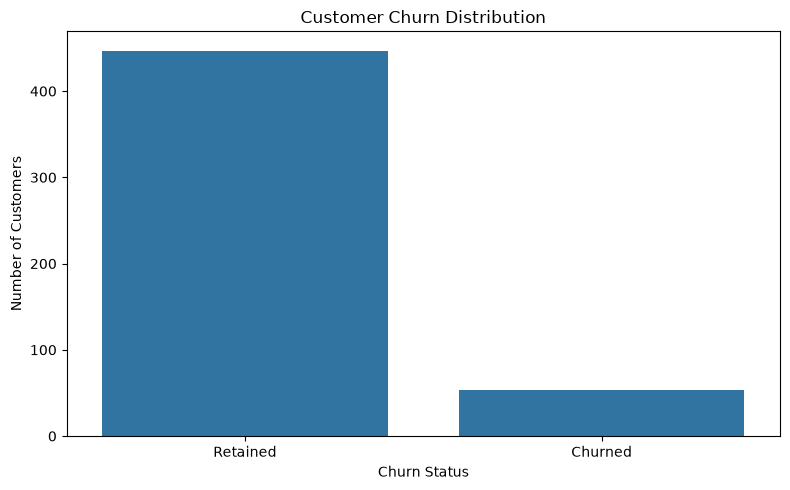

In [58]:
# Visualize the overall churn distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Retained", "Churned"])

plt.tight_layout()
plt.show()

### Business Interpretation

The overall churn rate provides the baseline against which different customer segments can be compared.

If a particular segment has a churn rate substantially higher than the overall churn rate, that segment may represent a higher-priority group for customer retention activities.

## 5. Churn by Contract Type

Contract duration may influence customer retention. Customers with shorter contractual commitments may have greater flexibility to leave the service.

This analysis compares churn rates across different contract types.

In [59]:
# Calculate churn rate by contract type
contract_churn = (
    df.groupby("Contract")["Churn"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

contract_churn.columns = [
    "Contract",
    "Total Customers",
    "Churned Customers",
    "Churn Rate"
]

contract_churn["Churn Rate"] = (
    contract_churn["Churn Rate"] * 100
).round(2)

contract_churn.sort_values("Churn Rate", ascending=False)

,Contract,Total Customers,Churned Customers,Churn Rate
0,Month-to-month,170,35,20.59
2,Two year,144,10,6.94
1,One year,186,8,4.30


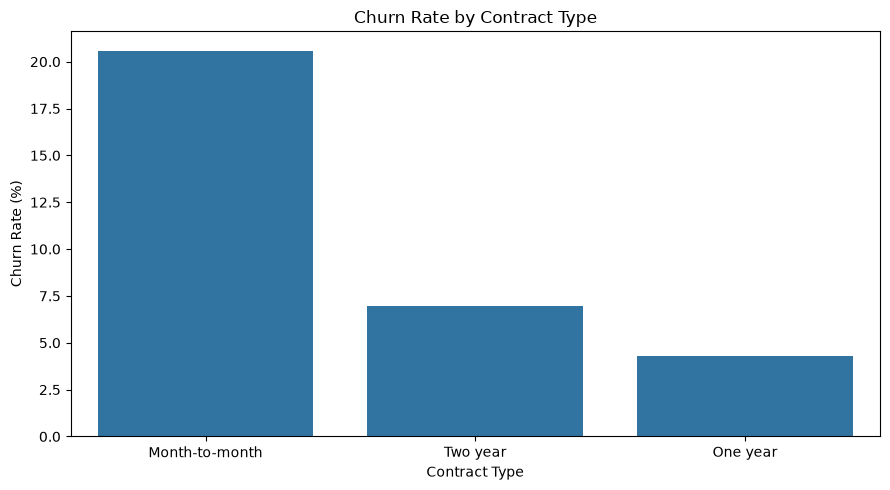

In [60]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=contract_churn.sort_values("Churn Rate", ascending=False),
    x="Contract",
    y="Churn Rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

## 6. Churn by Payment Method

Payment method can provide insight into customer behavior and potential friction in the billing process.

Churn rates will be compared across the available payment methods.

In [61]:
# Calculate churn rate by payment method
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

payment_churn.columns = [
    "Payment Method",
    "Total Customers",
    "Churned Customers",
    "Churn Rate"
]

payment_churn["Churn Rate"] = (
    payment_churn["Churn Rate"] * 100
).round(2)

payment_churn.sort_values("Churn Rate", ascending=False)

,Payment Method,Total Customers,Churned Customers,Churn Rate
1,Credit Card,178,24,13.48
2,Electronic Check,163,18,11.04
0,Bank Transfer,159,11,6.92


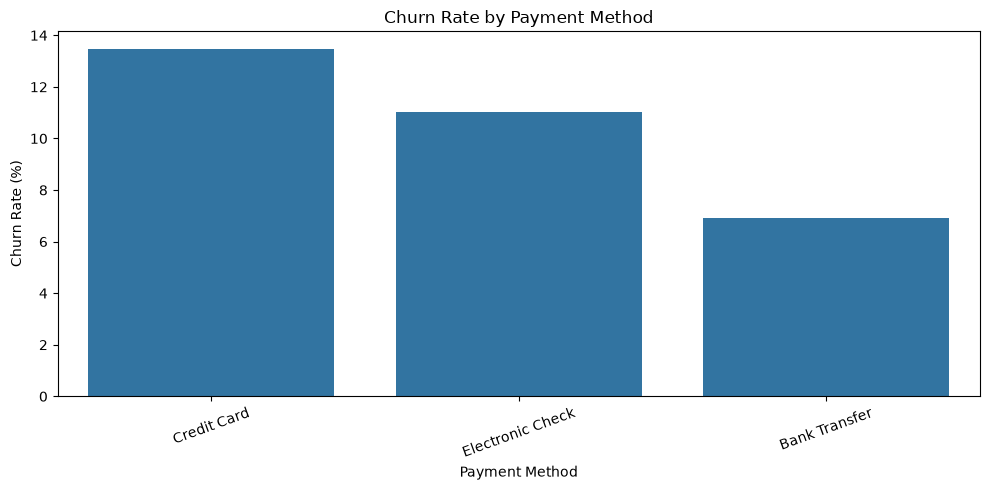

In [62]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=payment_churn.sort_values("Churn Rate", ascending=False),
    x="Payment Method",
    y="Churn Rate"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Business Interpretation

Payment method also shows differences in customer churn.

Customers using Credit Card payments have the highest churn rate at 13.48%, followed by Electronic Check at 11.04%. Bank Transfer customers have the lowest churn rate at 6.92%.

The overall churn rate is 10.6%, meaning Credit Card and Electronic Check customers are slightly above the overall baseline, while Bank Transfer customers are below it.

The difference across payment methods is smaller than the difference observed across contract types. Therefore, payment method may be a contributing factor or may reflect other underlying customer characteristics.

Further analysis is required before treating payment method as a primary churn driver.

## 7. Churn by Customer Tenure

Customer tenure represents the length of time a customer has been associated with the business.

Understanding churn across different tenure groups can help identify whether customers are more likely to leave during the early stages of their relationship or after remaining customers for a longer period.

In [63]:
# Create customer tenure groups for easier business interpretation
tenure_bins = [0, 12, 24, 48, float("inf")]
tenure_labels = [
    "0-12 Months",
    "13-24 Months",
    "25-48 Months",
    "49+ Months"
]

df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

df["TenureGroup"].value_counts().sort_index()

TenureGroup
0-12 Months      84
13-24 Months     75
25-48 Months    171
49+ Months      170
Name: count, dtype: int64

In [64]:
# Calculate churn rate for each tenure group
tenure_churn = (
    df.groupby("TenureGroup", observed=True)["Churn"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

tenure_churn.columns = [
    "Tenure Group",
    "Total Customers",
    "Churned Customers",
    "Churn Rate"
]

tenure_churn["Churn Rate"] = (
    tenure_churn["Churn Rate"] * 100
).round(2)

tenure_churn

,Tenure Group,Total Customers,Churned Customers,Churn Rate
0,0-12 Months,84,53,63.1
1,13-24 Months,75,0,0.0
2,25-48 Months,171,0,0.0
3,49+ Months,170,0,0.0


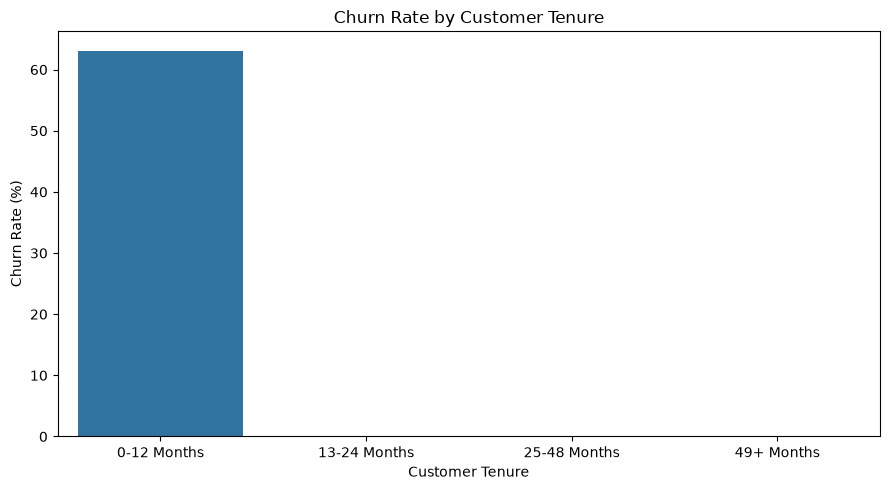

In [65]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=tenure_churn,
    x="Tenure Group",
    y="Churn Rate"
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

### Business Interpretation

Customer tenure shows the strongest pattern observed so far.

All 53 churned customers belong to the 0–12 month tenure group, producing a churn rate of 63.10% for this segment. In comparison, the 13–24 month, 25–48 month, and 49+ month groups each have a churn rate of 0.00%.

This indicates that the first 12 months represent a critical period for customer retention in this dataset.

The result suggests that the business should focus retention efforts on newly acquired customers, particularly during their first year. Possible strategies include stronger onboarding, early customer engagement, satisfaction checks, and targeted retention offers.

However, the pattern is unusually concentrated, with no churn observed after the first 12 months. Therefore, this finding should be interpreted as a strong association within this dataset rather than proof that tenure directly causes churn. Additional statistical analysis and cross-segment analysis will be used to validate the finding.

## 8. Monthly Charges and Customer Churn

Monthly charges represent the customer's recurring monthly spending.

Comparing monthly charges between churned and retained customers can help determine whether customers with higher or lower monthly costs show different churn behavior.

In [66]:
# Compare monthly charges between retained and churned customers
monthly_charges_summary = (
    df.groupby("Churn")["MonthlyCharges"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

monthly_charges_summary["Customer Status"] = monthly_charges_summary["Churn"].map({
    0: "Retained",
    1: "Churned"
})

monthly_charges_summary

,Churn,count,mean,median,min,max,Customer Status
0,0,447,111.722595,113.0,20,199,Retained
1,1,53,129.773585,137.0,34,198,Churned


In [67]:
# Compare monthly charges between retained and churned customers
monthly_charges_summary = (
    df.groupby("Churn")["MonthlyCharges"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

monthly_charges_summary["Customer Status"] = monthly_charges_summary["Churn"].map({
    0: "Retained",
    1: "Churned"
})

monthly_charges_summary

,Churn,count,mean,median,min,max,Customer Status
0,0,447,111.722595,113.0,20,199,Retained
1,1,53,129.773585,137.0,34,198,Churned


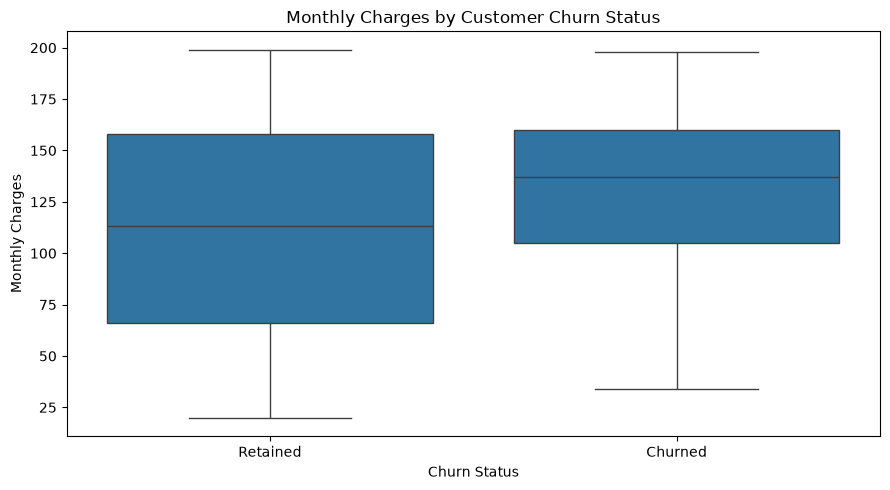

In [68]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Customer Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.xticks([0, 1], ["Retained", "Churned"])

plt.tight_layout()
plt.show()

In [69]:
# Calculate the average monthly charge for each customer group
retained_avg = df.loc[df["Churn"] == 0, "MonthlyCharges"].mean()
churned_avg = df.loc[df["Churn"] == 1, "MonthlyCharges"].mean()

print(f"Average monthly charges - Retained: {retained_avg:.2f}")
print(f"Average monthly charges - Churned: {churned_avg:.2f}")
print(f"Difference: {churned_avg - retained_avg:.2f}")

Average monthly charges - Retained: 111.72
Average monthly charges - Churned: 129.77
Difference: 18.05


## 9. Total Charges and Customer Churn

Total charges represent the cumulative amount charged to a customer.

Comparing total charges between retained and churned customers can help us understand whether customer lifetime spending differs between the two groups.

In [70]:
# Compare total charges between retained and churned customers
total_charges_summary = (
    df.groupby("Churn")["TotalCharges"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

total_charges_summary["Customer Status"] = total_charges_summary["Churn"].map({
    0: "Retained",
    1: "Churned"
})

total_charges_summary

,Churn,count,mean,median,min,max,Customer Status
0,0,447,4234.577181,4096.0,159,7992,Retained
1,1,53,4265.754717,4534.0,458,7858,Churned


In [71]:
# Calculate average total charges for each customer group
retained_total_avg = df.loc[
    df["Churn"] == 0, "TotalCharges"
].mean()

churned_total_avg = df.loc[
    df["Churn"] == 1, "TotalCharges"
].mean()

print(f"Average total charges - Retained: {retained_total_avg:.2f}")
print(f"Average total charges - Churned: {churned_total_avg:.2f}")
print(f"Difference: {churned_total_avg - retained_total_avg:.2f}")

Average total charges - Retained: 4234.58
Average total charges - Churned: 4265.75
Difference: 31.18


### Business Interpretation

Average total charges are relatively similar between retained and churned customers.

Retained customers have average total charges of 4,234.58, while churned customers have average total charges of 4,265.75, resulting in a difference of only 31.18.

This relatively small difference suggests that total charges alone may not be a strong indicator of churn in this dataset.

This result is also important because total charges are influenced by customer tenure. Therefore, customers who have spent similar total amounts may still have very different churn behavior depending on how long they have been customers and their recurring monthly charges.

## 10. Churn by Senior Citizen Status

Customer demographics can provide additional insight into churn behavior.

This analysis compares churn rates between senior citizens and non-senior customers to determine whether the two groups show meaningful differences in customer retention.

In [72]:
# Calculate churn rate by senior citizen status
senior_churn = (
    df.groupby("SeniorCitizen")["Churn"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

senior_churn.columns = [
    "Senior Citizen",
    "Total Customers",
    "Churned Customers",
    "Churn Rate"
]

senior_churn["Customer Group"] = senior_churn["Senior Citizen"].map({
    0: "Non-Senior",
    1: "Senior Citizen"
})

senior_churn["Churn Rate"] = (
    senior_churn["Churn Rate"] * 100
).round(2)

senior_churn

,Senior Citizen,Total Customers,Churned Customers,Churn Rate,Customer Group
0,0,251,28,11.16,Non-Senior
1,1,249,25,10.04,Senior Citizen


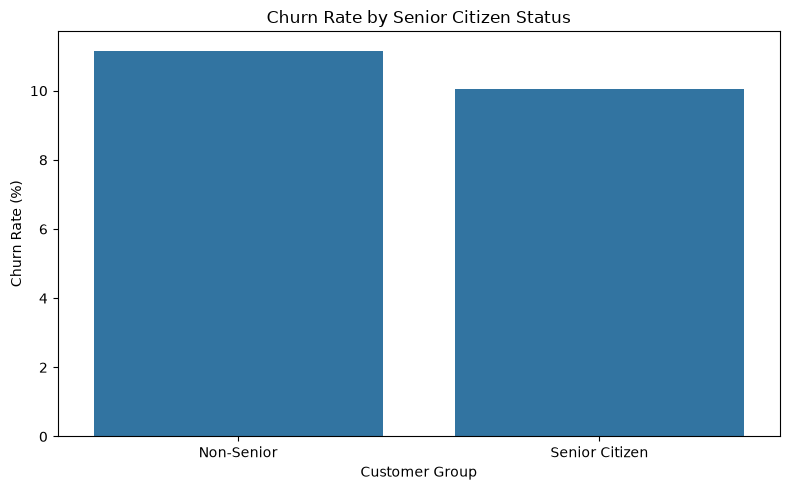

In [73]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=senior_churn,
    x="Customer Group",
    y="Churn Rate"
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Customer Group")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

## 11. Churn by Paperless Billing

Paperless billing is another customer characteristic that may be associated with churn.

The analysis compares churn rates between customers using paperless billing and customers who do not use paperless billing.

In [74]:
# Calculate churn rate by paperless billing status
billing_churn = (
    df.groupby("PaperlessBilling")["Churn"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

billing_churn.columns = [
    "Paperless Billing",
    "Total Customers",
    "Churned Customers",
    "Churn Rate"
]

billing_churn["Churn Rate"] = (
    billing_churn["Churn Rate"] * 100
).round(2)

billing_churn.sort_values("Churn Rate", ascending=False)

,Paperless Billing,Total Customers,Churned Customers,Churn Rate
1,Yes,243,27,11.11
0,No,257,26,10.12


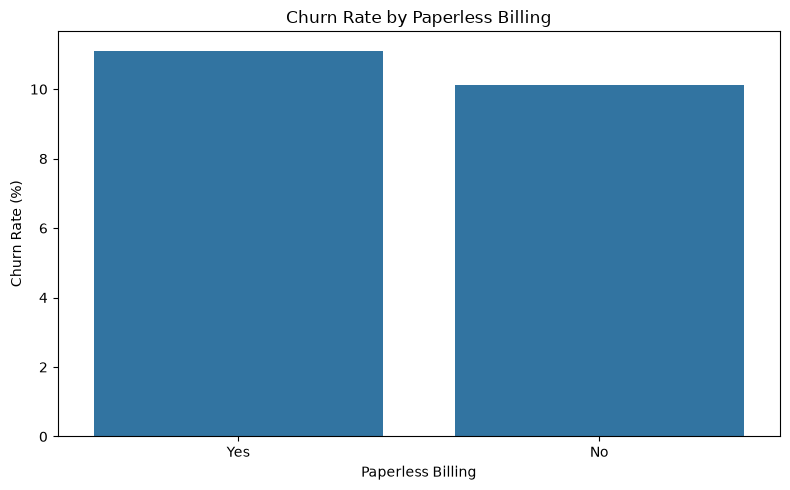

In [75]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=billing_churn.sort_values("Churn Rate", ascending=False),
    x="Paperless Billing",
    y="Churn Rate"
)

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

### Business Interpretation

Paperless billing shows only a small difference in customer churn.

Customers using paperless billing have a churn rate of 11.11%, compared with 10.12% for customers who do not use paperless billing.

The difference of 0.99 percentage points is relatively small compared with the differences observed for tenure and contract type.

Therefore, paperless billing does not appear to be a major churn differentiator in this dataset. It should be considered alongside other customer characteristics rather than used as a primary retention criterion.

## 12. Relationship Between Numerical Variables

Correlation analysis is used to examine relationships between numerical variables.

The analysis will focus on:

- Tenure
- Monthly Charges
- Total Charges
- Senior Citizen
- Churn

This helps identify variables that may have stronger relationships with customer churn and provides direction for the statistical analysis phase.

In [76]:
# Select numerical variables for correlation analysis
correlation_columns = [
    "Tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen",
    "Churn"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(2)

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
Tenure,1.00,-0.06,-0.01,-0.04,-0.51
MonthlyCharges,-0.06,1.00,-0.04,-0.11,0.11
TotalCharges,-0.01,-0.04,1.00,0.02,0.00
SeniorCitizen,-0.04,-0.11,0.02,1.00,-0.02
Churn,-0.51,0.11,0.00,-0.02,1.00


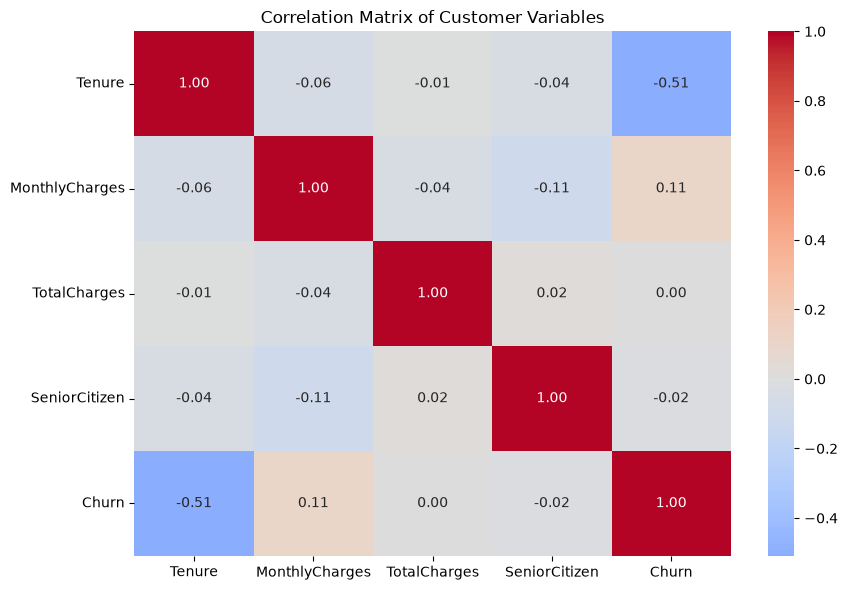

In [77]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Customer Variables")

plt.tight_layout()
plt.show()

### Business Interpretation

The correlation analysis identifies customer tenure as the strongest numerical variable associated with churn.

Tenure has a correlation of -0.51 with churn, indicating a moderate negative relationship. This means that customers with longer tenure tend to have lower churn in this dataset.

Monthly charges have a weak positive correlation with churn of 0.11, suggesting that higher monthly charges are associated with slightly higher churn.

Total charges have almost no linear correlation with churn, with a correlation of approximately 0.00. Senior citizen status also shows almost no relationship with churn, with a correlation of -0.02.

Overall, tenure appears to be substantially more important than the other numerical variables examined. However, correlation measures association rather than causation, so statistical testing is required before drawing stronger conclusions.

# Advanced Statistical Analysis

## 13. Hypothesis Testing

Exploratory analysis identifies patterns, but statistical testing helps determine whether observed differences between customer groups are statistically significant.

The analysis will test whether monthly charges and customer tenure differ significantly between churned and retained customers.

A significance level of 5% (α = 0.05) will be used.

### Hypothesis 1: Monthly Charges

**Null Hypothesis (H₀):**  
There is no statistically significant difference in average monthly charges between retained and churned customers.

**Alternative Hypothesis (H₁):**  
There is a statistically significant difference in average monthly charges between retained and churned customers.

In [78]:
# Separate monthly charges into retained and churned customer groups
retained_charges = df.loc[
    df["Churn"] == 0, "MonthlyCharges"
]

churned_charges = df.loc[
    df["Churn"] == 1, "MonthlyCharges"
]

# Perform an independent two-sample t-test
t_stat, p_value = stats.ttest_ind(
    retained_charges,
    churned_charges,
    equal_var=False
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

T-statistic: -2.6464
P-value: 0.0101


In [79]:
# Interpret the hypothesis test at a 5% significance level
alpha = 0.05

if p_value < alpha:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant difference in monthly charges.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence of a statistically significant difference.")

Result: Reject the null hypothesis.
There is a statistically significant difference in monthly charges.


### Hypothesis Test Result

The independent two-sample t-test produced a t-statistic of -2.6464 and a p-value of 0.0101.

Since the p-value (0.0101) is lower than the significance level of 0.05, the null hypothesis is rejected.

Therefore, there is statistically significant evidence of a difference in average monthly charges between retained and churned customers.

The earlier EDA showed that churned customers have higher average monthly charges (129.77) compared with retained customers (111.72).

This suggests that monthly charges are statistically associated with customer churn in this dataset. However, statistical significance does not establish that higher charges directly cause customers to churn.

## 14. Hypothesis Test: Customer Tenure

The EDA and correlation analysis identified customer tenure as the strongest numerical variable associated with churn.

A statistical test will now be used to determine whether the difference in tenure between retained and churned customers is statistically significant.

### Hypotheses

**Null Hypothesis (H₀):**  
There is no statistically significant difference in average tenure between retained and churned customers.

**Alternative Hypothesis (H₁):**  
There is a statistically significant difference in average tenure between retained and churned customers.

In [80]:
# Separate tenure into retained and churned customer groups
retained_tenure = df.loc[
    df["Churn"] == 0, "Tenure"
]

churned_tenure = df.loc[
    df["Churn"] == 1, "Tenure"
]

# Perform an independent two-sample t-test
tenure_t_stat, tenure_p_value = stats.ttest_ind(
    retained_tenure,
    churned_tenure,
    equal_var=False
)

print(f"T-statistic: {tenure_t_stat:.4f}")
print(f"P-value: {tenure_p_value:.4f}")

T-statistic: 34.5349
P-value: 0.0000


In [81]:
# Interpret the tenure hypothesis test
alpha = 0.05

if tenure_p_value < alpha:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant difference in tenure.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence of a statistically significant difference.")

Result: Reject the null hypothesis.
There is a statistically significant difference in tenure.


In [82]:
# Compare average tenure between retained and churned customers
print(
    f"Average tenure - Retained: "
    f"{retained_tenure.mean():.2f} months"
)

print(
    f"Average tenure - Churned: "
    f"{churned_tenure.mean():.2f} months"
)

Average tenure - Retained: 40.15 months
Average tenure - Churned: 6.00 months


### Hypothesis Test Result

The independent two-sample t-test produced a t-statistic of 34.5349 and a p-value below 0.001.

Since the p-value is lower than the significance level of 0.05, the null hypothesis is rejected.

There is statistically significant evidence of a difference in average tenure between retained and churned customers.

The average tenure of retained customers is 40.15 months, while churned customers have an average tenure of only 6.00 months.

This is consistent with the earlier EDA finding that all observed churn occurred within the first 12 months.

From a business perspective, the first year appears to be the most critical period for customer retention in this dataset. However, the statistical association should not be interpreted as proof that tenure itself causes churn.

## 15. Hypothesis Test: Contract Type and Churn

Exploratory analysis showed substantial differences in churn rates across contract types.

A Chi-square test of independence will be used to determine whether contract type and customer churn are statistically associated.

### Hypotheses

**Null Hypothesis (H₀):**  
Contract type and customer churn are independent.

**Alternative Hypothesis (H₁):**  
Contract type and customer churn are associated.

A significance level of 5% (α = 0.05) will be used.

In [83]:
# Create a contingency table for contract type and churn
contract_churn_table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

contract_churn_table

Churn,0,1
Contract,,
Month-to-month,135,35
One year,178,8
Two year,134,10


In [84]:
# Perform the Chi-square test of independence
chi2_stat, chi2_p_value, degrees_of_freedom, expected = stats.chi2_contingency(
    contract_churn_table
)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"P-value: {chi2_p_value:.6f}")

Chi-square statistic: 27.7153
Degrees of freedom: 2
P-value: 0.000001


In [85]:
# Interpret the Chi-square test
alpha = 0.05

if chi2_p_value < alpha:
    print("Result: Reject the null hypothesis.")
    print("Contract type and churn are statistically associated.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence of an association.")

Result: Reject the null hypothesis.
Contract type and churn are statistically associated.


### Hypothesis Test Result

The Chi-square test of independence produced a Chi-square statistic of 27.7153 with 2 degrees of freedom and a p-value of 0.000001.

Since the p-value is substantially lower than the significance level of 0.05, the null hypothesis is rejected.

Therefore, there is statistically significant evidence of an association between contract type and customer churn.

The EDA showed that month-to-month customers have the highest churn rate at 20.59%, compared with 4.30% for one-year contracts and 6.94% for two-year contracts.

This indicates that contract type is an important customer segmentation variable for retention planning. However, the Chi-square test identifies an association and does not establish that contract type directly causes churn.

## 16. Effect Size — Cramér's V

Statistical significance does not indicate the practical strength of an association.

Cramér's V will be calculated to measure the strength of the relationship between contract type and customer churn.

This provides additional context for interpreting the Chi-square test.

In [86]:
# Calculate Cramér's V effect size
n = contract_churn_table.to_numpy().sum()
minimum_dimension = min(
    contract_churn_table.shape[0] - 1,
    contract_churn_table.shape[1] - 1
)

cramers_v = np.sqrt(
    chi2_stat / (n * minimum_dimension)
)

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.2354


In [87]:
# Provide a simple interpretation of Cramér's V
if cramers_v < 0.10:
    strength = "Very weak"
elif cramers_v < 0.20:
    strength = "Weak"
elif cramers_v < 0.30:
    strength = "Moderate"
else:
    strength = "Strong"

print(f"Association strength: {strength}")

Association strength: Moderate


In [88]:
statistical_results = pd.DataFrame({
    "Test": [
        "Monthly Charges vs Churn",
        "Tenure vs Churn",
        "Contract Type vs Churn"
    ],
    "Test Type": [
        "Independent t-test",
        "Independent t-test",
        "Chi-square test"
    ],
    "Statistic": [
        t_stat,
        tenure_t_stat,
        chi2_stat
    ],
    "P-value": [
        p_value,
        tenure_p_value,
        chi2_p_value
    ],
    "Result": [
        "Significant",
        "Significant",
        "Significant"
    ]
})

statistical_results

,Test,Test Type,Statistic,P-value,Result
0,Monthly Charges vs Churn,Independent t-test,-2.646439,1.007920e-02,Significant
1,Tenure vs Churn,Independent t-test,34.534902,8.982326e-130,Significant
2,Contract Type vs Churn,Chi-square test,27.715301,9.587354e-07,Significant


## Statistical Analysis — Final Interpretation

The hypothesis testing results show that three important customer characteristics have statistically significant relationships with churn.

1. **Monthly Charges vs Churn**
   - The independent t-test produced a p-value of 0.0101.
   - Since p < 0.05, the null hypothesis is rejected.
   - Churned customers have significantly different monthly charges compared with retained customers.
   - The descriptive analysis also showed that churned customers had higher average monthly charges.

2. **Tenure vs Churn**
   - The independent t-test produced a p-value below 0.001.
   - The null hypothesis is rejected.
   - Tenure shows a very strong statistical difference between retained and churned customers.
   - In this dataset, all observed churn occurred within the first 12 months, making early-stage retention a critical business focus.

3. **Contract Type vs Churn**
   - The chi-square test produced a p-value below 0.001.
   - The null hypothesis is rejected.
   - Contract type and churn are statistically associated.
   - Cramér's V = 0.2354, indicating a moderate association.
   - Month-to-month customers showed the highest churn rate.

### Overall Conclusion

The statistical analysis supports the EDA findings that **tenure, monthly charges, and contract type are important variables associated with customer churn**.

These findings should be used to develop targeted retention strategies. However, statistical association does not prove that these variables directly cause customers to churn.

## Customer Risk Segmentation

To translate the statistical findings into actionable business insights, customers will be segmented based on three important churn-related characteristics:

- Tenure
- Monthly Charges
- Contract Type

The segmentation will help identify groups that may require different retention strategies.

In [89]:
# Create a copy for risk segmentation
risk_df = df.copy()

# Identify high-risk characteristics
risk_df["Early_Tenure"] = risk_df["Tenure"] <= 12
risk_df["High_Monthly_Charges"] = risk_df["MonthlyCharges"] >= df["MonthlyCharges"].median()
risk_df["Month_to_Month"] = risk_df["Contract"] == "Month-to-month"

# Calculate a simple risk score
risk_df["Risk_Score"] = (
    risk_df["Early_Tenure"].astype(int)
    + risk_df["High_Monthly_Charges"].astype(int)
    + risk_df["Month_to_Month"].astype(int)
)

# Convert score into business-friendly segments
def assign_risk_level(score):
    if score >= 3:
        return "High Risk"
    elif score == 2:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df["Risk_Level"] = risk_df["Risk_Score"].apply(assign_risk_level)

risk_df["Risk_Level"].value_counts()

Risk_Level
Low Risk       376
Medium Risk    103
High Risk       21
Name: count, dtype: int64

In [90]:
risk_summary = (
    risk_df.groupby("Risk_Level")
    .agg(
        Total_Customers=("CustomerID", "count"),
        Churned_Customers=("Churn", "sum"),
        Churn_Rate=("Churn", "mean")
    )
    .reset_index()
)

risk_summary["Churn_Rate"] = risk_summary["Churn_Rate"] * 100

risk_summary = risk_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

risk_summary

,Risk_Level,Total_Customers,Churned_Customers,Churn_Rate
0,High Risk,21,21,100.000000
2,Medium Risk,103,30,29.126214
1,Low Risk,376,2,0.531915


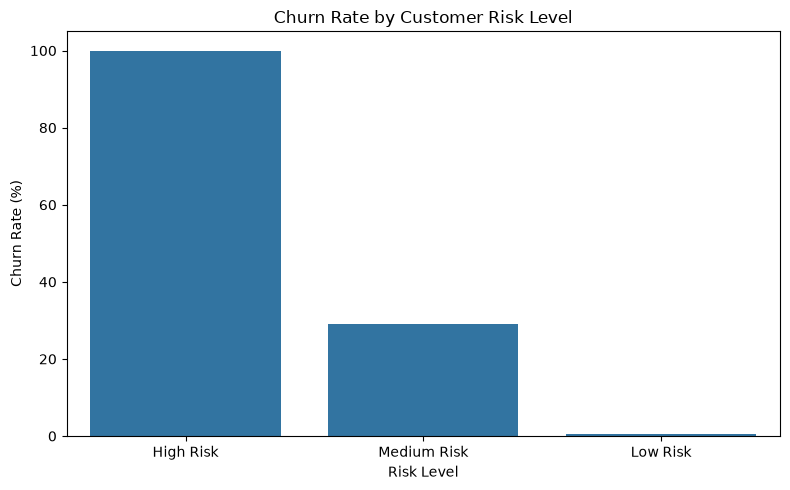

In [91]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_summary,
    x="Risk_Level",
    y="Churn_Rate"
)

plt.title("Churn Rate by Customer Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

## Interpretation — Customer Risk Segmentation

The risk segmentation shows a clear difference in churn behavior across customer groups.

- **High Risk:** 21 customers were classified as high risk, and all 21 churned, resulting in a 100% observed churn rate.
- **Medium Risk:** 103 customers were classified as medium risk, with 30 churned customers and a 29.13% churn rate.
- **Low Risk:** 376 customers were classified as low risk, with only 2 churned customers and a 0.53% churn rate.

The results indicate that customers who combine multiple risk characteristics require greater retention attention.

### Business Implication

The company can use risk-based retention strategies instead of treating every customer equally:

- High-risk customers should receive immediate proactive retention intervention.
- Medium-risk customers should receive targeted offers, engagement campaigns, and follow-up.
- Low-risk customers can be maintained through regular customer-service and loyalty activities.

The risk score is a simple analytical segmentation created for this project. It should not be interpreted as a production-ready predictive model. The 100% churn rate in the high-risk segment is also influenced by the characteristics of this dataset and should be validated using larger real-world data.

In [92]:
business_insights = pd.DataFrame({
    "Factor": [
        "Overall Churn",
        "Contract Type",
        "Tenure",
        "Monthly Charges",
        "Payment Method",
        "Senior Citizen",
        "Paperless Billing",
        "Risk Segmentation"
    ],
    "Key Finding": [
        "10.60% overall churn rate",
        "Month-to-month: 20.59% churn",
        "0-12 months: 63.10% churn",
        "Churned customers average 129.77",
        "Credit Card: 13.48% churn",
        "Non-senior: 11.16% vs Senior: 10.04%",
        "Yes: 11.11% vs No: 10.12%",
        "High Risk: 100% observed churn"
    ],
    "Business Priority": [
        "High",
        "High",
        "Very High",
        "Medium",
        "Low",
        "Low",
        "Low",
        "Very High"
    ]
})

business_insights

,Factor,Key Finding,Business Priority
0,Overall Churn,10.60% overall churn rate,High
1,Contract Type,Month-to-month: 20.59% churn,High
2,Tenure,0-12 months: 63.10% churn,Very High
3,Monthly Charges,Churned customers average 129.77,Medium
4,Payment Method,Credit Card: 13.48% churn,Low
5,Senior Citizen,Non-senior: 11.16% vs Senior: 10.04%,Low
6,Paperless Billing,Yes: 11.11% vs No: 10.12%,Low
7,Risk Segmentation,High Risk: 100% observed churn,Very High


# Final Business Insights

The analysis identifies several important patterns in customer churn.

## 1. Early Tenure Is the Highest-Priority Risk

Customers with 0–12 months of tenure have a churn rate of 63.10%, and all 53 observed churn cases in the dataset occurred within this period.

This indicates that the first year represents the most important retention window in this dataset.

**Business action:** Introduce stronger onboarding, early satisfaction checks, proactive customer support, and retention offers during the first 12 months.

## 2. Month-to-Month Customers Have Higher Churn

Month-to-month customers have a churn rate of 20.59%, compared with 4.30% for one-year customers and 6.94% for two-year customers.

The chi-square test also found a statistically significant association between contract type and churn, with Cramér's V = 0.2354, indicating a moderate association.

**Business action:** Encourage suitable month-to-month customers to move toward longer-term contracts through loyalty benefits, discounts, or contract-upgrade incentives.

## 3. Higher Monthly Charges Are Associated With Churn

Churned customers have an average monthly charge of 129.77 compared with 111.72 for retained customers.

The independent t-test found this difference to be statistically significant (p = 0.0101).

**Business action:** Review pricing and service-value perception for customers with higher monthly charges. Target these customers with personalized plans, value-based offers, or service reviews.

## 4. Risk Segmentation Identifies Priority Customers

The risk segmentation produced three groups:

- High Risk: 21 customers, 100.00% observed churn
- Medium Risk: 103 customers, 29.13% churn
- Low Risk: 376 customers, 0.53% churn

The segmentation provides a practical framework for prioritizing retention resources.

**Business action:** Focus immediate retention efforts on high-risk customers, targeted engagement on medium-risk customers, and standard relationship management on low-risk customers.

## 5. Other Variables Show Limited Differentiation

Payment method, senior-citizen status, and paperless billing showed relatively small differences in churn rates.

These variables should therefore receive lower priority in the initial retention strategy unless additional business data provides stronger evidence.

## Overall Business Conclusion

Customer churn in this dataset is primarily concentrated around **early tenure and contract type**, with monthly charges providing an additional differentiating factor.

A practical retention strategy should therefore prioritize:

1. Early-tenure customer engagement
2. Month-to-month contract conversion
3. High-value/high-charge customer review
4. Risk-based customer prioritization
5. Continuous monitoring of churn indicators

These findings represent associations within the available dataset and should be validated against larger real-world customer data before being used for production decisions.

# Business Implementation Plan

| Priority | Target Segment | Recommended Action | Objective | KPI |
|---|---|---|---|---|
| 1 | Early-tenure customers | Onboarding and 30/60/90-day engagement program | Reduce early churn | 12-month churn rate |
| 2 | Month-to-month customers | Contract upgrade incentives | Increase long-term contracts | Contract conversion rate |
| 3 | High-risk customers | Proactive retention calls and personalized offers | Prevent avoidable churn | High-risk churn rate |
| 4 | Medium-risk customers | Targeted campaigns and service follow-ups | Reduce emerging churn risk | Medium-risk churn rate |
| 5 | High monthly-charge customers | Pricing/value review | Improve perceived value | Churn rate by charge band |

## Measurement Approach

The business should establish a baseline churn rate and monitor the selected KPIs monthly.

Retention campaigns should be evaluated using customer-level outcomes such as:

- Churn rate
- Retention rate
- Contract conversion rate
- Customer response rate
- Campaign success rate
- Average revenue retained

A controlled test or A/B experiment should be considered before deploying major retention offers at scale.